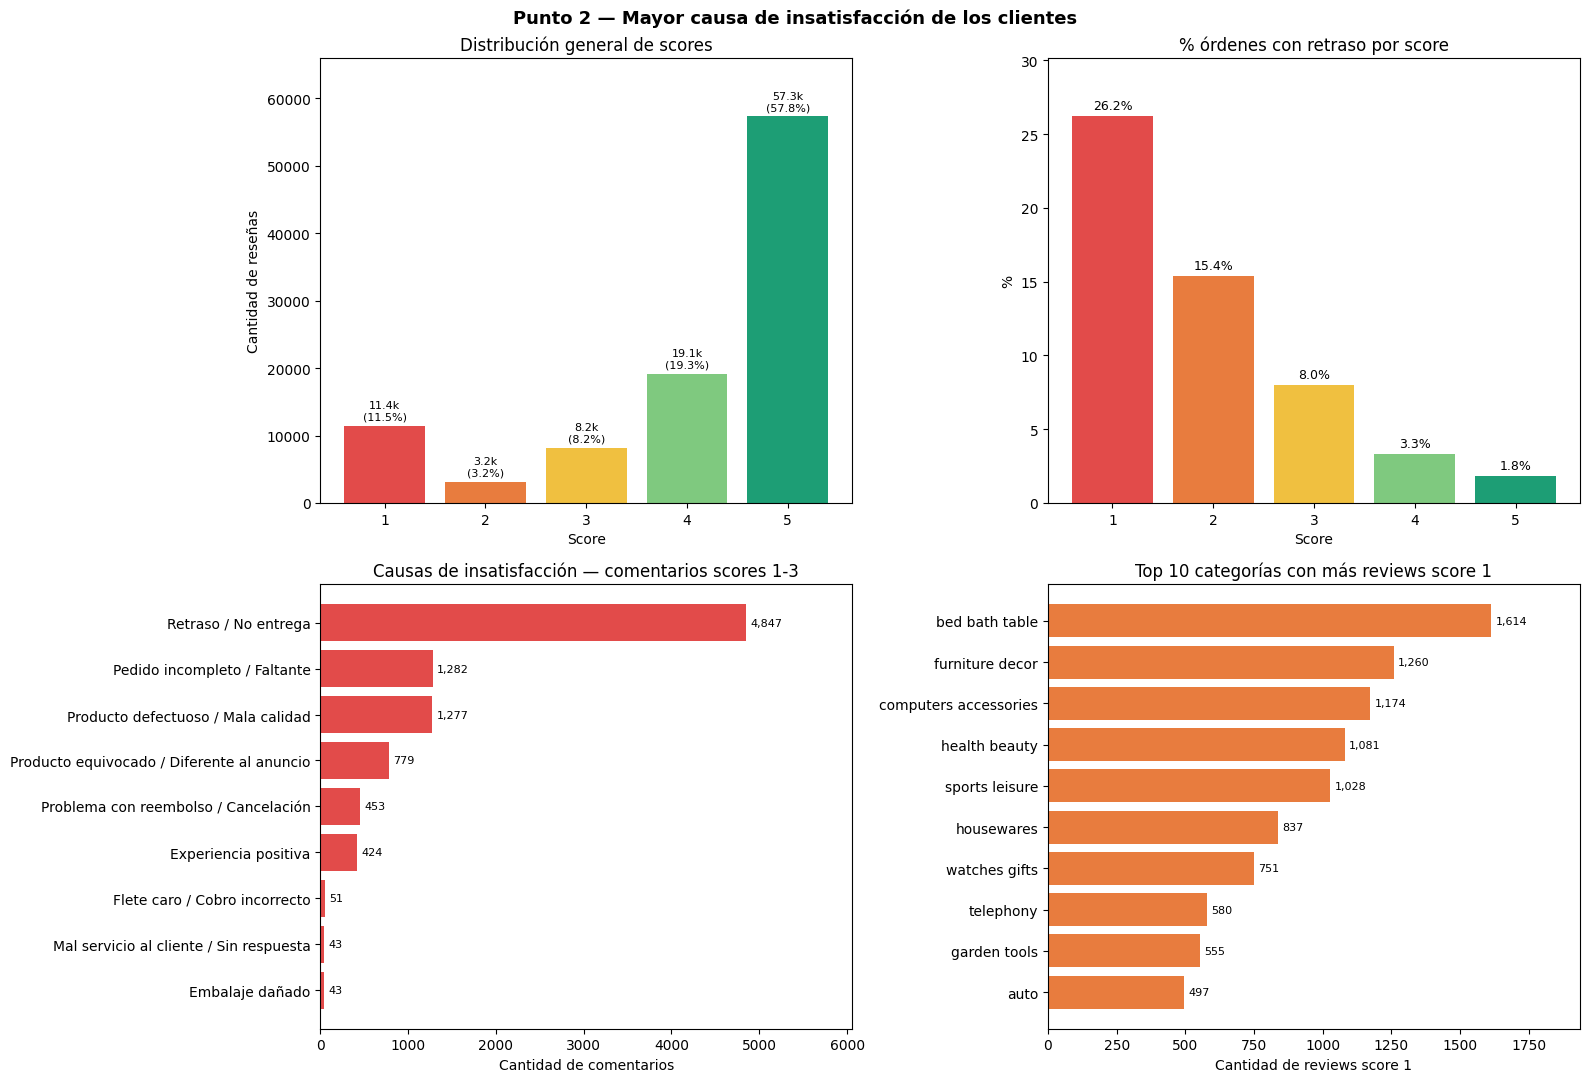

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Carga ─────────────────────────────────────────────────────────────────────
orders      = pd.read_csv('orders_dataset.csv')
reviews     = pd.read_csv('order_reviews_dataset.csv')
items       = pd.read_csv('order_items_dataset.csv')
products    = pd.read_csv('products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
translation.columns = translation.columns.str.replace('\ufeff', '')
clasificados = pd.read_csv('comments_clasificados.csv')

orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

# ── Join ──────────────────────────────────────────────────────────────────────
df = (
    reviews
    .merge(orders[['order_id', 'delay_days']], on='order_id', how='left')
    .merge(items[['order_id', 'product_id']], on='order_id', how='left')
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(translation, on='product_category_name', how='left')
)
df['category'] = df['product_category_name_english'].fillna(df['product_category_name'])
df['retrasado'] = df['delay_days'] > 0

# ── Datos ─────────────────────────────────────────────────────────────────────
# 1. Distribución general de scores
score_dist     = reviews['review_score'].value_counts().sort_index()
score_dist_pct = score_dist / score_dist.sum() * 100

# 2. % retraso por score
retraso_score = df.groupby('review_score')['retrasado'].mean().mul(100).round(1)

# 3. Causas clasificadas (sin "Sin categoría", solo scores 1-3)
causas = (
    clasificados[clasificados['categoria'] != 'Sin categoría']
    ['categoria'].value_counts()
)

# 4. Top 10 categorías con más reviews score 1
top_bad = (
    df[df['review_score'] == 1]
    .groupby('category')['review_score'].count()
    .sort_values(ascending=False).head(10)
)

 # ── Gráficos ──────────────────────────────────────────────────────────────────
SCORE_COLORS = ['#e24b4a', '#e87c3e', '#f0c040', '#7fc97f', '#1d9e75']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Punto 2 — Mayor causa de insatisfacción de los clientes', fontsize=13, fontweight='bold')

# 1. Distribución general de scores
bars1 = axes[0, 0].bar(score_dist.index, score_dist.values, color=SCORE_COLORS)
axes[0, 0].set_title('Distribución general de scores')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Cantidad de reseñas')
axes[0, 0].set_ylim(0, score_dist.max() * 1.15)
axes[0, 0].bar_label(bars1, labels=[f'{v/1000:.1f}k\n({score_dist_pct[i]:.1f}%)' for i, v in score_dist.items()], padding=3, fontsize=8)

# 2. % retraso por score
bars2 = axes[0, 1].bar(retraso_score.index, retraso_score.values, color=SCORE_COLORS)
axes[0, 1].set_title('% órdenes con retraso por score')
axes[0, 1].set_xlabel('Score')
axes[0, 1].set_ylabel('%')
axes[0, 1].set_ylim(0, retraso_score.max() * 1.15)
axes[0, 1].bar_label(bars2, labels=[f'{v:.1f}%' for v in retraso_score.values], padding=3, fontsize=9)

# 3. Causas clasificadas de scores 1-3
bars3 = axes[1, 0].barh(causas.index, causas.values, color='#e24b4a')
axes[1, 0].set_title('Causas de insatisfacción — comentarios scores 1-3')
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Cantidad de comentarios')
axes[1, 0].set_xlim(0, causas.max() * 1.25)
axes[1, 0].bar_label(bars3, labels=[f'{v:,}' for v in causas.values], padding=3, fontsize=8)

# 4. Top 10 categorías con score 1
bars4 = axes[1, 1].barh(top_bad.index.str.replace('_', ' '), top_bad.values, color='#e87c3e')
axes[1, 1].set_title('Top 10 categorías con más reviews score 1')
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel('Cantidad de reviews score 1')
axes[1, 1].set_xlim(0, top_bad.max() * 1.2)
axes[1, 1].bar_label(bars4, labels=[f'{v:,}' for v in top_bad.values], padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('punto_2.png', dpi=150, bbox_inches='tight')